# Análise de Classificação de Popularidade Literária: Regressão Logística

Este notebook documenta o desenvolvimento, otimização e avaliação de um modelo estatístico linear probabilístico (Regressão Logística) para prever o potencial de popularidade de obras literárias com base em seus metadados de pré-lançamento. 

O objetivo principal desta etapa é estabelecer um **baseline linear robusto**. Diferente de modelos baseados em árvores ou abordagens de aprendizado profundo, a Regressão Logística oferece total transparência na interpretação dos coeficientes, permitindo isolar a contribuição estatística de cada atributo e garantindo a explicabilidade necessária para a validação metodológica do projeto.

## 1. Engenharia de Atributos, Preparação e Divisão dos Dados

Nesta fase, os dados processados são preparados para o modelamento estatístico. A engenharia de variáveis (*Feature Engineering*) é realizada de forma controlada para garantir a integridade do processo e evitar o *Data Leakage*.

Para garantir a validade estatística da avaliação e simular um cenário real de inferência, adotamos o seguinte protocolo:

1. **Divisão Estratificada (80/20):** O conjunto de dados é dividido antes de qualquer cálculo de frequência ou normalização. O parâmetro de estratificação assegura que a proporção das classes (Bestseller, Média Popularidade e Nicho) seja preservada tanto no treino quanto no teste.
2. **Engenharia de Atributos Orientada ao Treino:** O cálculo de frequência histórica dos autores e a definição dos formatos de maior representatividade (*Top Formats*) são realizados **estritamente sobre o conjunto de treinamento**. O conjunto de teste é mapeado utilizando essas métricas calculadas no treino, tratando valores inéditos como "Outros" ou com valor nulo, evitando que informações futuras vazem para o modelo.
3. **Padronização Escore-Z Isolada:** Após a engenharia, aplicamos o `StandardScaler`. O cálculo de médias e desvios-padrão é computado exclusivamente sobre o conjunto de treinamento, sendo apenas aplicado, posteriormente, ao conjunto de teste. 

Este fluxo garante que o modelo aprenda padrões de generalização robustos, mantendo o conjunto de teste como uma amostra "cega" e confiável para a validação final.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# 1. Carga dos dados processados e cruzamento estrutural (Merge)
df_generos = pd.read_parquet('../data/processed/books_pivot_mapped.parquet')
df_original = pd.read_parquet('../data/processed/books_clean.parquet')

df_class = pd.merge(
    df_original[['title', 'author', 'bookformat', 'pages', 'totalratings']], 
    df_generos, 
    on=['title', 'author'], 
    how='inner'
)

# 1.1 Limpeza pós-merge: Remove as duplicatas da tabela da direita e renomeia as da esquerda
df_class = df_class.drop(columns=['pages_y', 'totalratings_y', 'rating'], errors='ignore')
df_class = df_class.rename(columns={'pages_x': 'pages', 'totalratings_x': 'totalratings'})

# 2. Definição da Variável Alvo (3 Classes de Popularidade)
def definir_tres_classes(ratings):
    if ratings >= 10000:
        return 1  # Bestseller
    elif ratings >= 1000:
        return 2  # Média Popularidade
    else:
        return 3  # Nicho
    
df_class['popularity_class'] = df_class['totalratings'].apply(definir_tres_classes)

# 3. Divisão Estratificada
df_train, df_test = train_test_split(
    df_class, 
    test_size=0.2, 
    random_state=42, 
    stratify=df_class['popularity_class']
)

# Criamos cópias para evitar o aviso "SettingWithCopyWarning" do Pandas
df_train = df_train.copy()
df_test = df_test.copy()

# 4. Engenharia de Atributos
# 4.1. Frequência do Autor (Mapeamento de histórico)
autor_frequencia_treino = df_train['author'].value_counts()

df_train['author_frequency'] = df_train['author'].map(autor_frequencia_treino)
# Se um autor aparecer no Teste mas não existir no Treino, o Pandas retorna NaN. Preenchemos com 0.
df_test['author_frequency'] = df_test['author'].map(autor_frequencia_treino).fillna(0)

# 4.2. Tratamento do Formato do Livro (Top 5 extraídos APENAS do Treino)
top_formatos_treino = df_train['bookformat'].value_counts().index[:5]

df_train['format_grouped'] = df_train['bookformat'].apply(lambda x: x if x in top_formatos_treino else 'Other')
df_test['format_grouped'] = df_test['bookformat'].apply(lambda x: x if x in top_formatos_treino else 'Other')

# 4.3. Codificação Categórica (Dummies)
df_formatos_train = pd.get_dummies(df_train['format_grouped'], prefix='format', drop_first=True)
df_formatos_test = pd.get_dummies(df_test['format_grouped'], prefix='format', drop_first=True)

# Alinhamento de segurança: Garante que o teste tenha exatamente as mesmas colunas do treino
df_formatos_test = df_formatos_test.reindex(columns=df_formatos_train.columns, fill_value=0)

# 5. Definição das variáveis macro-gênero mapeadas
macro_generos = [
    'Artes, Lazer e Estilo de Vida', 'Fantasia e Ficção Científica', 
    'Ficção Geral e Literatura', 'História e Biografia', 
    'Infantojuvenil e Quadrinhos', 'Mistério, Thriller e Terror', 
    'Não-Ficção e Autodesenvolvimento', 'Outros', 'Romance'
]

# 6. Consolidação das Matrizes de Treino (X_train) e Teste (X_test)
x_train = pd.concat([df_train[['pages', 'author_frequency']], df_formatos_train, df_train[macro_generos]], axis=1).astype(float)
y_train = df_train['popularity_class']

x_test = pd.concat([df_test[['pages', 'author_frequency']], df_formatos_test, df_test[macro_generos]], axis=1).astype(float)
y_test = df_test['popularity_class']


## 2. Padronização de Atributos e Prevenção de Data Leakage

A Regressão Logistíca calcula distâncias e otimiza uma função de perda que é diretamente afetada pela escala das variáveis. 

Para mitigar o **Data Leakage** (vazamento de dados), o ajuste do escore-Z (`StandardScaler`) é computado **estritamente sobre o conjunto de treino** (`fit_transform`). O conjunto de teste é apenas transformado (`transform`) utilizando as médias e desvios padrão calculados previamente na base de treino. Isso garante que informações do futuro (teste) não influenciem o aprendizado do modelo.

In [35]:
from sklearn.preprocessing import StandardScaler

# Inicialização do padronizador 
scaler = StandardScaler()

# Ajuste e transformação baseados exclusivamente no treino
x_train_scaled = scaler.fit_transform(x_train)

# Transformação do teste para simular o ambiente produtivo
x_test_scaled = scaler.transform(x_test)

print(f"Dimensões do Conjunto de Treino: {x_train_scaled.shape}")
print(f"Dimensões do Conjunto de Teste: {x_test_scaled.shape}")

Dimensões do Conjunto de Treino: (65604, 16)
Dimensões do Conjunto de Teste: (16402, 16)


## 3. Otimização de Hiperparâmetros e Tratamento de Desbalanceamento

Visando maximizar o poder de generalização do  modelo sem o descarte artifical de dados (comum em técnicas de subamostragem), o parãmetro `class-weight='balanced'`. Este método introduz uma **matriz de custo** na função de perda penalizando de forma inversamente proporcional a frequência das classes, forçando o algoritmo a aprender os padrões das categorias minoritárias.

A sintonia do hiperparâmetro de regularização inversa ($C$) é conduzida via `GridSearchCV` associada a uma validação cruzada em 5 folds ($k=5$). A métrica de otimização escolhida é o **F1-Macro**, ideal por ponderar o equilíbrio entre precisão e sensibilidade de forma justa entre todas as classes.

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Definição do espaço de busca paramétrica
param_grid = {
    'C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
    'solver': ['lbfgs'],
    'max_iter': [1000]
}

# Estruturação da validação cruzada com penalização de custo balanceada
grid_lr = GridSearchCV(
    estimator=LogisticRegression(random_state=42, class_weight='balanced'),
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

# Execução da Otimização estatística
grid_lr.fit(x_train_scaled, y_train)

# Extração do estimador ótimo
melhor_lr = grid_lr.best_estimator_
print(f"Parâmetro ótimo de regularização inversa (C): {grid_lr.best_params_['C']}")

Parâmetro ótimo de regularização inversa (C): 100.0


## 4. Avaliação Metodológica do Desempenho

A validação final do classificador é realizada confrontando as previsões obtidas contra um conjunto de teste isolado. A avaliaç;ão baseia-se no tripé estatístico de classificação de dados não balanceados:

* **Precision (Precisão):** Capacidade do modelo de não classificar uma obra incorretamente.
* **Recall (Sensibilidade):** Capacidade de mapear a totalidade dos casos reais de uma classe.
* **F1-Score:** Média harmônica que penaliza desequilíbrios severos entre precisão e sensibilidade.

In [42]:
from sklearn.metrics import classification_report, accuracy_score

# 1. Geração das predições estatísticas para ambas as etapas
previsoes_lr_teste = melhor_lr.predict(x_test_scaled)
previsoes_lr_treino = melhor_lr.predict(x_train_scaled)

# 2. Exibir relatórios de desempenho
print("=======================================================================")
print("          RELATÓRIO DE DESEMPENHO - TREINO (REGRESSÃO LOGÍSTICA)       ")
print("=======================================================================")
print(f"Acurácia Global (Treino): {accuracy_score(y_train, previsoes_lr_treino) * 100:.2f}%\n")
print(classification_report(y_train, previsoes_lr_treino, target_names=['Classe 1', 'Classe 2', 'Classe 3']))


print("=======================================================================")
print("          RELATÓRIO DE DESEMPENHO - TESTE (REGRESSÃO LOGÍSTICA)        ")
print("=======================================================================")
print(f"Acurácia Global: {accuracy_score(y_test, previsoes_lr_teste) * 100:.2f}%\n")
print(classification_report(y_test, previsoes_lr_teste, target_names=['Bestsellers', 'Média Popularidade', 'Nicho']))
print("=======================================================================")

          RELATÓRIO DE DESEMPENHO - TREINO (REGRESSÃO LOGÍSTICA)       
Acurácia Global (Treino): 61.21%

              precision    recall  f1-score   support

    Classe 1       0.13      0.59      0.22      2924
    Classe 2       0.32      0.40      0.36     13194
    Classe 3       0.91      0.67      0.77     49486

    accuracy                           0.61     65604
   macro avg       0.46      0.55      0.45     65604
weighted avg       0.76      0.61      0.66     65604

          RELATÓRIO DE DESEMPENHO - TESTE (REGRESSÃO LOGÍSTICA)        
Acurácia Global: 62.22%

                    precision    recall  f1-score   support

       Bestsellers       0.14      0.57      0.22       731
Média Popularidade       0.33      0.41      0.36      3299
             Nicho       0.91      0.68      0.78     12372

          accuracy                           0.62     16402
         macro avg       0.46      0.55      0.45     16402
      weighted avg       0.76      0.62      0.67     

## 4.1. Análise Visual de Erros (Matriz de Confusão)

A matriz de confusão quantifica de forma cruzada as classificações exatas (diagonal principal) e os desvios cometidos pelo estimador. Essa análise permite diagnosticar se as falhas do modelo ocorrem por proximidade conceitual (ex: classificar um Bestseller como Média Popularidade) ou por erros severos de fronteira linear.



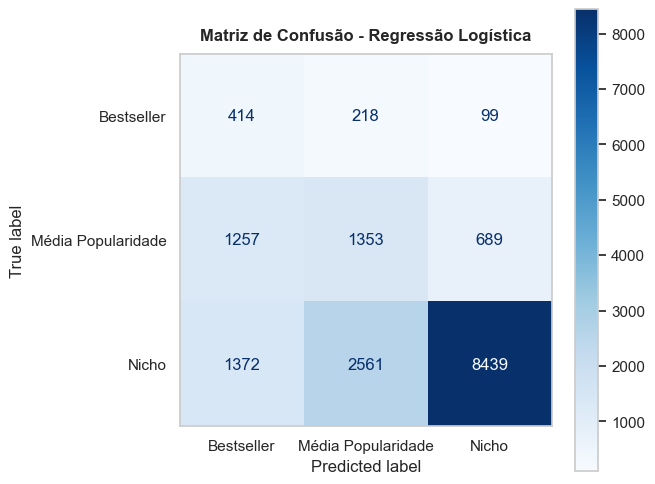

In [38]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Computação da matriz de erros
cm = confusion_matrix(y_test, previsoes_lr_teste)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Bestseller', 'Média Popularidade', 'Nicho'])

# Renderização do mapa de calor
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title("Matriz de Confusão - Regressão Logística", fontsize=12, fontweight='bold', pad=10)
plt.grid(False)
plt.show()

## 5. Análise de Coeficientes e Significância das Variáveis

Como as variáveis de entrada foram previamente submetidas à padronização escore-Z, a magnitude dos coeficientes finais da Regressão Logística torna-se diretamente comparável.

* **Coeficientes Positivos (Barras Azuis):** Indicam atributos que elevam significativamente a probabilidade de a obra pertencer à classe analisada (fatores de propensão).
* **Coeficientes Negativos (Barras Vermelhas):** Apontam para atributos que reduzem a probabilidade da obra atingir o respectivo nível de popularidade (fatores de mitigação).

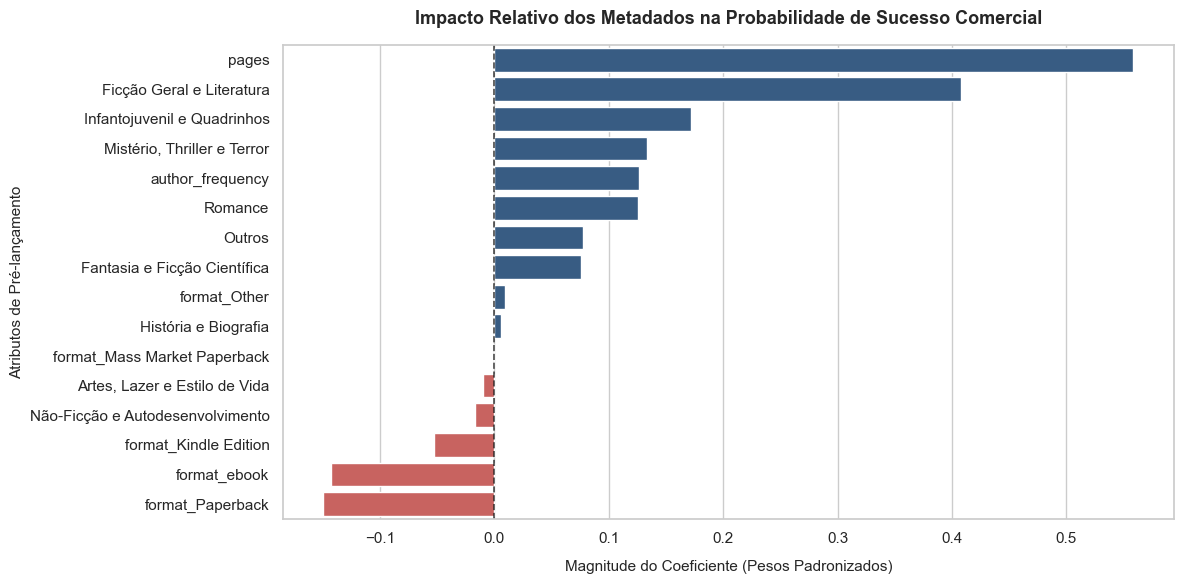

In [39]:
import seaborn as sns

# Extração dos pesos da classe de interesse (Classe 1 - Bestsellers)
coeficientes_classe1 = melhor_lr.coef_[0]

# Estruturação da tabela descritiva de impactos
df_coeficientes = pd.DataFrame({
    'Atributo': x_train.columns,
    'Coeficiente (Peso)': coeficientes_classe1
}).sort_values(by='Coeficiente (Peso)', ascending=False)

# Mapeamento cromático condicional à direção do impacto
df_coeficientes['Direcao_Cor'] = np.where(df_coeficientes['Coeficiente (Peso)'] >= 0, '#2b5c8f', '#d9534f')

# Construção do gráfico de relevância de atributos
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

sns.barplot(
    x='Coeficiente (Peso)', 
    y='Atributo', 
    hue='Atributo',
    legend=False,
    data=df_coeficientes, 
    palette=df_coeficientes['Direcao_Cor'].tolist()
)

plt.axvline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.7)
plt.title('Impacto Relativo dos Metadados na Probabilidade de Sucesso Comercial', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Magnitude do Coeficiente (Pesos Padronizados)', fontsize=11, labelpad=10)
plt.ylabel('Atributos de Pré-lançamento', fontsize=11)
plt.tight_layout()
plt.show()

## 6. Exportação do Estimador

Validada a consistência estatística do baseline, o modelo otimizado e calibrado é persistido em formato binário (.pkl) utilizando a biblioteca `joblib`. Esse procedimento assegura a reprodutibilidade dos resultados e possibilita a integração direta do artefato matemático com o ambiente de produção da aplicação final.

In [ ]:
import joblib
import os

# Estruturação do repositório físico de persistência
models_dir = os.path.abspath(os.path.join(os.getcwd(), "..", "..", "Machine Learning", "models"))
os.makedirs(models_dir, exist_ok=True)

# Exportação do modelo serializado
joblib.dump(melhor_lr, os.path.join(models_dir, "lr_popularidade.pkl"))
print("Modelo de Regressão Logística persistido com sucesso para a produção do App!")